In [1]:
import requests
from bs4 import BeautifulSoup as bs
import pandas as pd

In [3]:
# wbdriver -> 웹 브라우저를 제어
from selenium import webdriver
# By -> element(Tag) 접근하기 위한 기능
from selenium.webdriver.common.by import By
# Keys -> 키보드의 이벤트들
from selenium.webdriver.common.keys import Keys


In [11]:
# 웹 브라우져를 실행
driver = webdriver.Chrome()

In [12]:
# 웹 브라우저에 주소를 입력
driver.get('http://www.naver.com')

#### selenium 안에 webdriver에서 Tag를 찾는 내장 함수
- find_element()
    - 특정 조건에 맞는 태그 중 첫번째 태그를 선택
    - bs에서 find() 흡사한 기능
- find_elements()
    - 특정 조건에 맞는 태그 모두를 추출
    - bs에서 find_all() 흡사한 기능
    - tag들이 모인 list형태라 생각하시면 됨


In [13]:
# 네이버 메인 화면에서 검색어를 입력하는 input tag는 id가 query이다.
search_element = driver.find_element(By.ID, 'query')

In [14]:
# search_element -> 검색어 입력창
# 입력할 데이터를 보내준다. python에서 webdriver로 보낸다.
search_element.send_keys('아이폰')

In [15]:
# 검색어의 입력이 끝났으면 Enter키를 눌러서 검색을 시작
search_element.send_keys(Keys.ENTER)

In [17]:
# 하이퍼링크의 콘텐츠 데이터가 '쇼핑'인 태그를 선택
len(driver.find_elements(By.LINK_TEXT, '쇼핑'))

1

In [18]:
shopping_button = driver.find_element(By.LINK_TEXT, '쇼핑')

In [19]:
# 쇼핑 버튼을 클릭한다.
shopping_button.click()

'<html lang="ko" data-useragent="mozilla/5.0 (windows nt 10.0; win64; x64) applewebkit/537.36 (khtml, like gecko) chrome/147.0.0.0 safari/537.36" data-platform="win32"><head> <meta charset="utf-8"> <meta name="referrer" content="strict-origin-when-cross-origin">  <meta name="format-detection" content="telephone=no,address=no,email=no"> <meta property="og:title" content="아이폰 : 네이버 검색"> <meta property="og:image" content="https://ssl.pstatic.net/sstatic/search/common/og_v3.png"> <meta property="og:description" content="\'아이폰\'의 네이버 검색 결과입니다."> <meta name="description" lang="ko" content="\'아이폰\'의 네이버 검색 결과입니다."> <title>아이폰 : 네이버 검색</title> <link rel="shortcut icon" href="https://ssl.pstatic.net/sstatic/search/favicon/favicon_32x32_240820.ico">  <link rel="search" type="application/opensearchdescription+xml" href="https://ssl.pstatic.net/sstatic/search/opensearch-description.https.xml" title="Naver"><link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/sstatic/search/pc/css/s
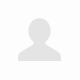
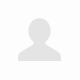
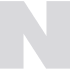
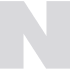

In [20]:
# 웹 브라우저(driver)에 있는 html 문서를 python으로 가져온다.
driver.page_source

In [23]:
html_data = driver.page_source
soup = bs(html_data, 'html.parser')
soup.title

<title>아이폰 : 네이버 검색</title>

In [24]:
# driver에 탭이 2개가 생기는 경우 일반적으로 driver.page_source를 가져오면 1번 탭의 정보를 제공
# 탭의 정보(주소)를 가져온다.

driver.window_handles

['22FFA22FCA93ACB7AD6512BEFA65EC81', '4C1C6AFE1EC67FA1F44D40566DF2BC1C']

In [25]:
# driver에서 탭을 이동 : 창을 변경 swich_to.window(탭의 정보)
driver.switch_to.window(
    driver.window_handles[1]
)

In [26]:
html_data = driver.page_source
soup = bs(html_data, 'html.parser')

In [27]:
soup.title

<title data-next-head="">아이폰 : 네이버 가격비교</title>

In [28]:
# 상품의 정보가 모두 들어있는 영역인 div 태그 중 id가 content 태그를 추출
items_div = soup.find(
    'div'
)